# Exploration des données — Sleep Apnea Detection

Ce notebook explore les données PSG du challenge ENS #45 :
- Structure des fichiers H5
- Distribution des labels (taux d'apnée, durée des événements)
- Analyse par sujet
- Visualisation des signaux

In [2]:
import sys
sys.path.insert(0, '..')

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.data.dataset import load_data, SIGNAL_NAMES
from src.data.preprocessing import compute_stats, normalize, clip_outliers
from src.training.metrics import extract_events

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Chargement des données

In [3]:
signals, labels, sample_ids, subject_ids = load_data(
    '../X_train.h5',
    '../data/X_train_h7ipJUo.csv',
    '../data/y_train_tX9Br0C.csv',
)

print(f"Signaux  : {signals.shape}  (n_fenêtres, n_signaux, n_samples)")
print(f"Labels   : {labels.shape}  (n_fenêtres, 90 secondes)")
print(f"Sujets   : {np.unique(subject_ids).tolist()}")
print(f"Taux d'apnée global : {labels.mean():.3%}")

Signaux  : (4400, 8, 9000)  (n_fenêtres, n_signaux, n_samples)
Labels   : (4400, 90)  (n_fenêtres, 90 secondes)
Sujets   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Taux d'apnée global : 6.872%


## 2. Distribution des labels

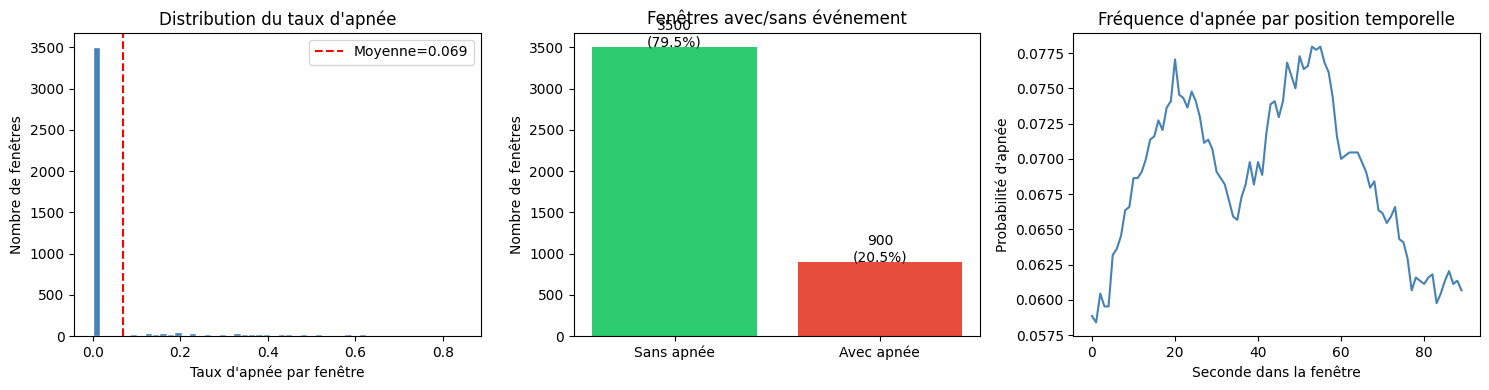

In [4]:
# Taux d'apnée par fenêtre
apnea_rate_per_window = labels.mean(axis=1)  # (4400,)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogramme du taux d'apnée par fenêtre
axes[0].hist(apnea_rate_per_window, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Taux d\'apnée par fenêtre')
axes[0].set_ylabel('Nombre de fenêtres')
axes[0].set_title('Distribution du taux d\'apnée')
axes[0].axvline(apnea_rate_per_window.mean(), color='red', linestyle='--', label=f'Moyenne={apnea_rate_per_window.mean():.3f}')
axes[0].legend()

# Proportion de fenêtres sans apnée vs avec
no_apnea = (apnea_rate_per_window == 0).sum()
with_apnea = (apnea_rate_per_window > 0).sum()
axes[1].bar(['Sans apnée', 'Avec apnée'], [no_apnea, with_apnea], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Fenêtres avec/sans événement')
axes[1].set_ylabel('Nombre de fenêtres')
for i, v in enumerate([no_apnea, with_apnea]):
    axes[1].text(i, v + 10, f'{v}\n({v/len(labels):.1%})', ha='center')

# Distribution de la position temporelle des labels=1
label_freq = labels.mean(axis=0)  # (90,)
axes[2].plot(range(90), label_freq, color='steelblue')
axes[2].set_xlabel('Seconde dans la fenêtre')
axes[2].set_ylabel('Probabilité d\'apnée')
axes[2].set_title('Fréquence d\'apnée par position temporelle')

plt.tight_layout()
plt.show()

## 3. Durée des événements d'apnée

Nombre total d'événements : 1486
Durée moyenne : 18.3s  (médiane=17.0s)
Durée min/max : 1s / 70s
Événements par fenêtre (mean) : 0.34


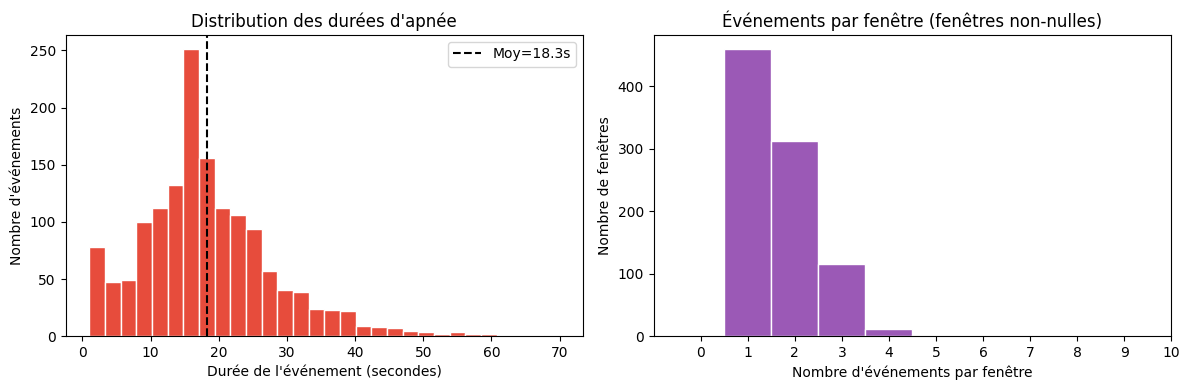

In [5]:
event_durations = []
events_per_window = []

for mask in labels:
    evts = extract_events(mask.astype(int))
    events_per_window.append(len(evts))
    for start, end in evts:
        event_durations.append(end - start)  # en secondes

event_durations = np.array(event_durations)
events_per_window = np.array(events_per_window)

print(f"Nombre total d'événements : {len(event_durations)}")
print(f"Durée moyenne : {event_durations.mean():.1f}s  (médiane={np.median(event_durations):.1f}s)")
print(f"Durée min/max : {event_durations.min()}s / {event_durations.max()}s")
print(f"Événements par fenêtre (mean) : {events_per_window.mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(event_durations, bins=30, color='#e74c3c', edgecolor='white')
axes[0].set_xlabel('Durée de l\'événement (secondes)')
axes[0].set_ylabel('Nombre d\'événements')
axes[0].set_title('Distribution des durées d\'apnée')
axes[0].axvline(event_durations.mean(), color='black', linestyle='--', label=f'Moy={event_durations.mean():.1f}s')
axes[0].legend()

axes[1].hist(events_per_window[events_per_window > 0], bins=range(0, 11), color='#9b59b6', edgecolor='white', align='left')
axes[1].set_xlabel('Nombre d\'événements par fenêtre')
axes[1].set_ylabel('Nombre de fenêtres')
axes[1].set_title('Événements par fenêtre (fenêtres non-nulles)')
axes[1].set_xticks(range(0, 11))

plt.tight_layout()
plt.show()

## 4. Analyse par sujet

         n_windows  apnea_rate  total_events
subject                                     
0              200    0.009889            12
1              200    0.029000            17
2              200    0.095611            99
3              200    0.079667            80
4              200    0.272389           206
5              200    0.079667            77
6              200    0.057500            50
7              200    0.069500            67
8              200    0.137722           157
9              200    0.011278            16
10             200    0.103056           115
11             200    0.021167            18
12             200    0.121833           130
13             200    0.016333            19
14             200    0.011500            12
15             200    0.034056            48
16             200    0.059333            65
17             200    0.007444            10
18             200    0.192111           172
19             200    0.016278            21
20        

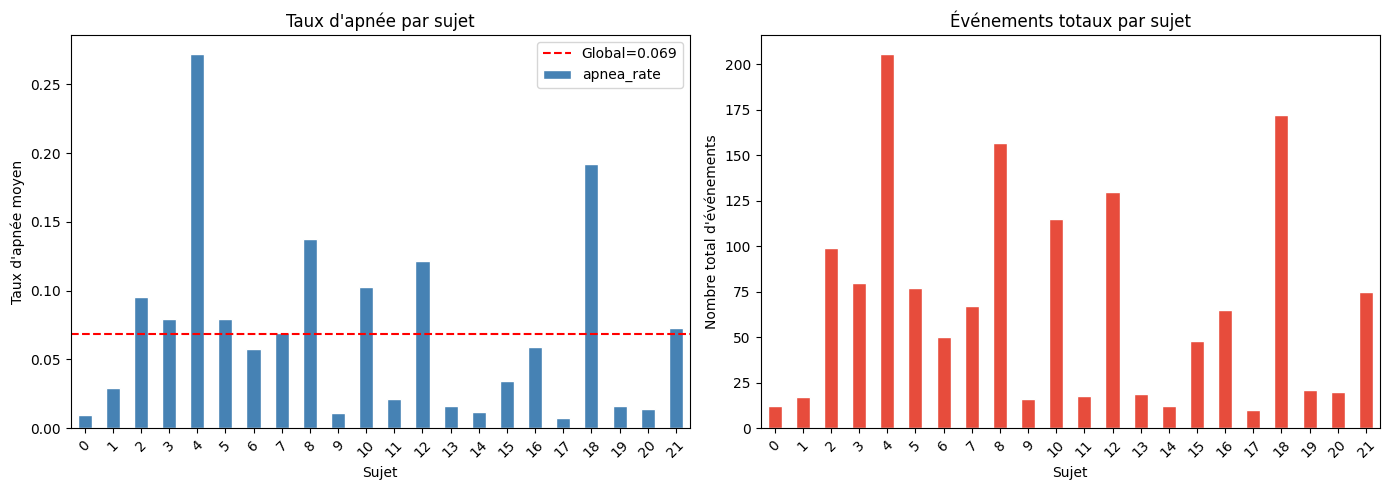

In [6]:
subjects = np.unique(subject_ids)
subject_stats = []

for subj in subjects:
    mask = subject_ids == subj
    subj_labels = labels[mask]
    subj_rate = subj_labels.mean()
    subj_events = sum(len(extract_events(row.astype(int))) for row in subj_labels)
    subject_stats.append({
        'subject': subj,
        'n_windows': mask.sum(),
        'apnea_rate': subj_rate,
        'total_events': subj_events,
    })

df_subjects = pd.DataFrame(subject_stats).set_index('subject')
print(df_subjects.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_subjects['apnea_rate'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Sujet')
axes[0].set_ylabel('Taux d\'apnée moyen')
axes[0].set_title('Taux d\'apnée par sujet')
axes[0].axhline(labels.mean(), color='red', linestyle='--', label=f'Global={labels.mean():.3f}')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

df_subjects['total_events'].plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Sujet')
axes[1].set_ylabel('Nombre total d\'événements')
axes[1].set_title('Événements totaux par sujet')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Statistiques des signaux

In [7]:
# Statistiques brutes par canal
print("Statistiques brutes par canal :")
print(f"{'Signal':>12} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
print('-' * 64)
for i, name in enumerate(SIGNAL_NAMES):
    ch = signals[:, i, :].ravel()
    print(f"{name:>12} {ch.mean():>12.2f} {ch.std():>12.2f} {ch.min():>12.2f} {ch.max():>12.2f}")

# Normalisation
mean, std = compute_stats(signals)
signals_norm = clip_outliers(normalize(signals, mean, std))

print(f"\nAprès normalisation : min={signals_norm.min():.2f}  max={signals_norm.max():.2f}")

Statistiques brutes par canal :
      Signal         Mean          Std          Min          Max
----------------------------------------------------------------
    AbdoBelt         5.89       480.81     -1145.48      1181.55
     AirFlow       -28.40        57.31      -455.25       351.57
         PPG      -857.78      1513.29     -4995.01      4348.31
    ThorBelt        -9.01       432.78     -1187.90      1183.39
     Snoring       693.81       463.94     -1171.44      1224.01
        SPO2     91942.33     16592.62         6.68    105313.70
        C4A1         0.00        21.45     -2521.74      2555.46
        O2A1        -0.00        20.70     -2667.76      2660.12

Après normalisation : min=-5.00  max=5.00


## 6. Visualisation d'une fenêtre

Fenêtres avec apnée : 900


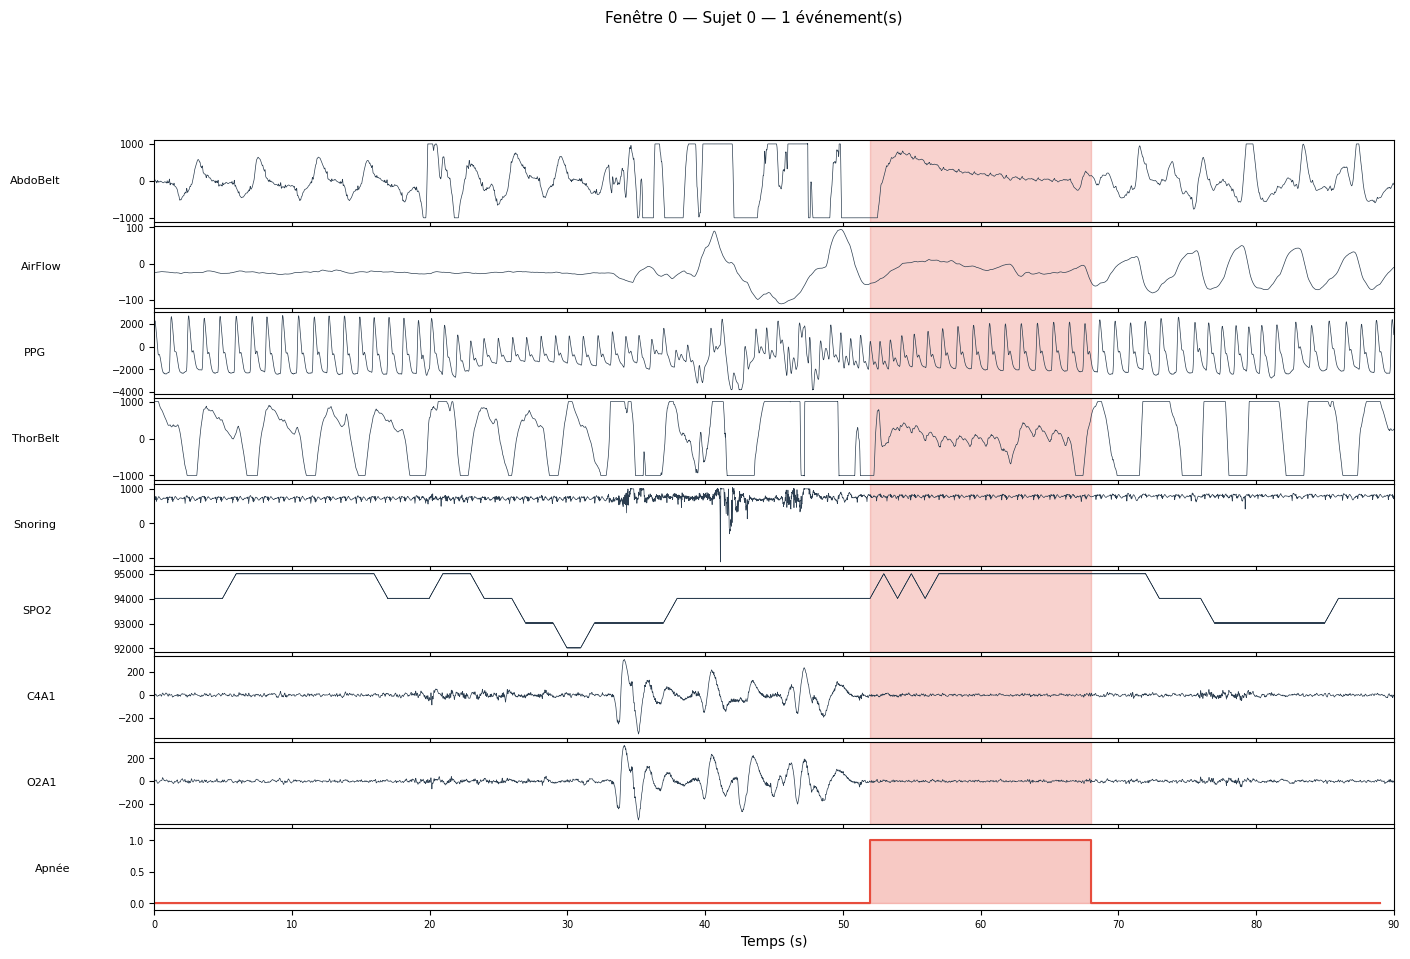

In [8]:
def plot_window(idx, signals, labels, normalized=False):
    """Affiche les 8 signaux et les événements d'apnée pour une fenêtre."""
    x = signals[idx]  # (8, 9000)
    y = labels[idx]   # (90,)
    
    events = extract_events(y.astype(int))
    t_signal = np.arange(9000) / 100  # en secondes
    t_label  = np.arange(90)          # en secondes
    
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(9, 1, hspace=0.05)
    
    for i, name in enumerate(SIGNAL_NAMES):
        ax = fig.add_subplot(gs[i])
        ax.plot(t_signal, x[i], linewidth=0.5, color='#2c3e50')
        ax.set_ylabel(name, fontsize=8, rotation=0, labelpad=55, va='center')
        ax.set_xlim(0, 90)
        ax.tick_params(labelbottom=False, labelsize=7)
        for start, end in events:
            ax.axvspan(start, end, color='#e74c3c', alpha=0.25)
    
    # Label row
    ax_label = fig.add_subplot(gs[8])
    ax_label.step(t_label, y, where='post', color='#e74c3c', linewidth=1.5)
    ax_label.fill_between(t_label, y, step='post', alpha=0.3, color='#e74c3c')
    ax_label.set_ylabel('Apnée', fontsize=8, rotation=0, labelpad=55, va='center')
    ax_label.set_xlim(0, 90)
    ax_label.set_ylim(-0.1, 1.2)
    ax_label.set_xlabel('Temps (s)')
    ax_label.tick_params(labelsize=7)
    
    title = f"Fenêtre {idx} — Sujet {subject_ids[idx]} — {len(events)} événement(s)"
    if normalized:
        title += " [normalisé]"
    fig.suptitle(title, y=1.01, fontsize=11)
    plt.show()


# Fenêtre avec apnée
windows_with_apnea = np.where(labels.sum(axis=1) > 0)[0]
print(f"Fenêtres avec apnée : {len(windows_with_apnea)}")
plot_window(windows_with_apnea[0], signals, labels)

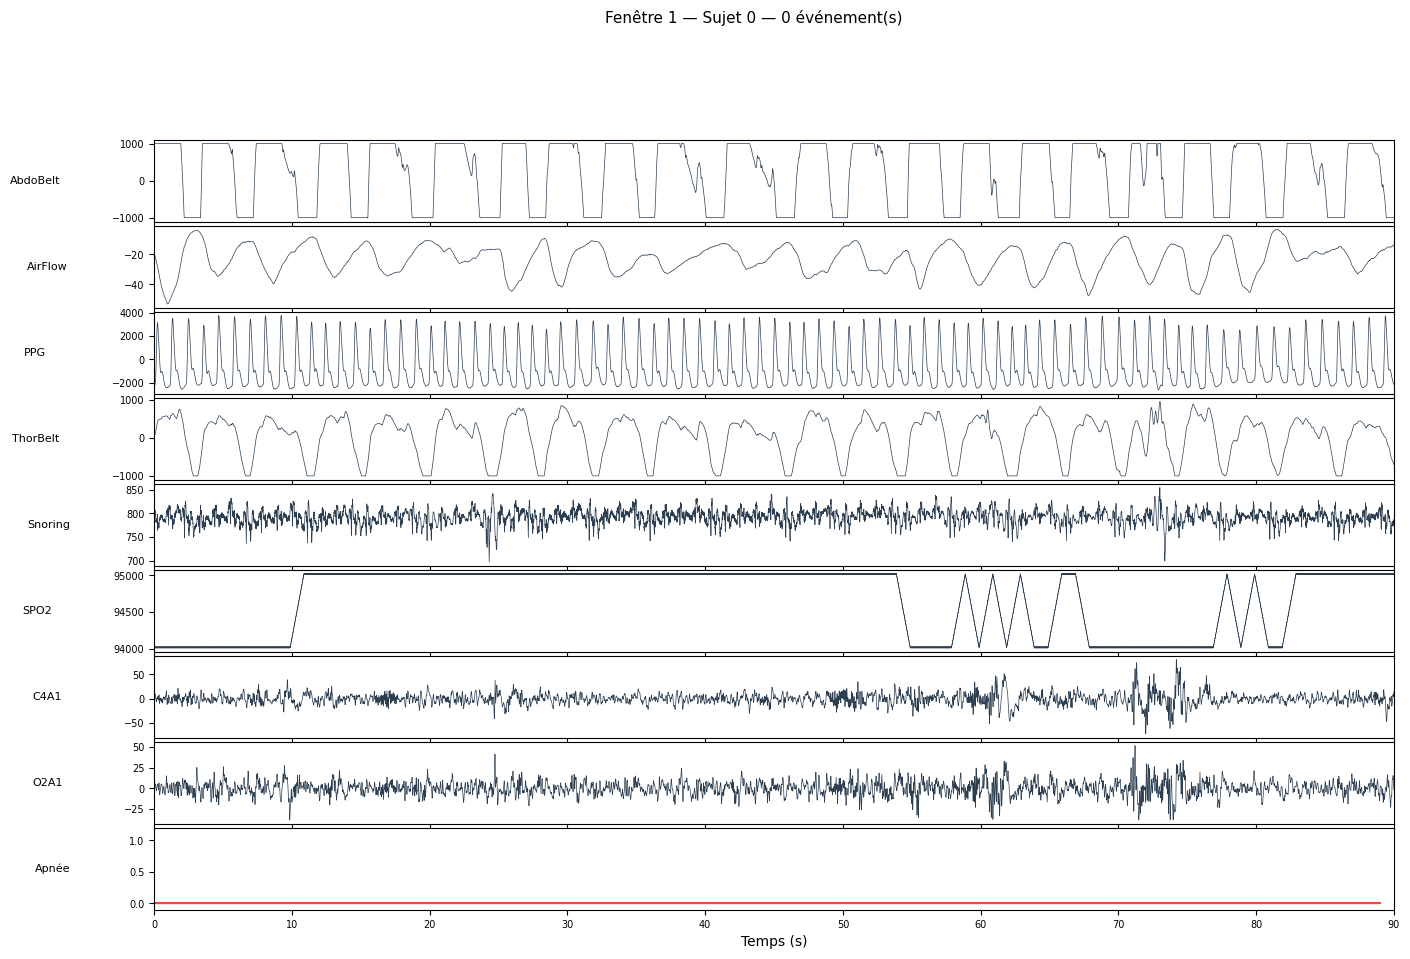

In [9]:
# Fenêtre sans apnée pour comparaison
windows_no_apnea = np.where(labels.sum(axis=1) == 0)[0]
plot_window(windows_no_apnea[0], signals, labels)

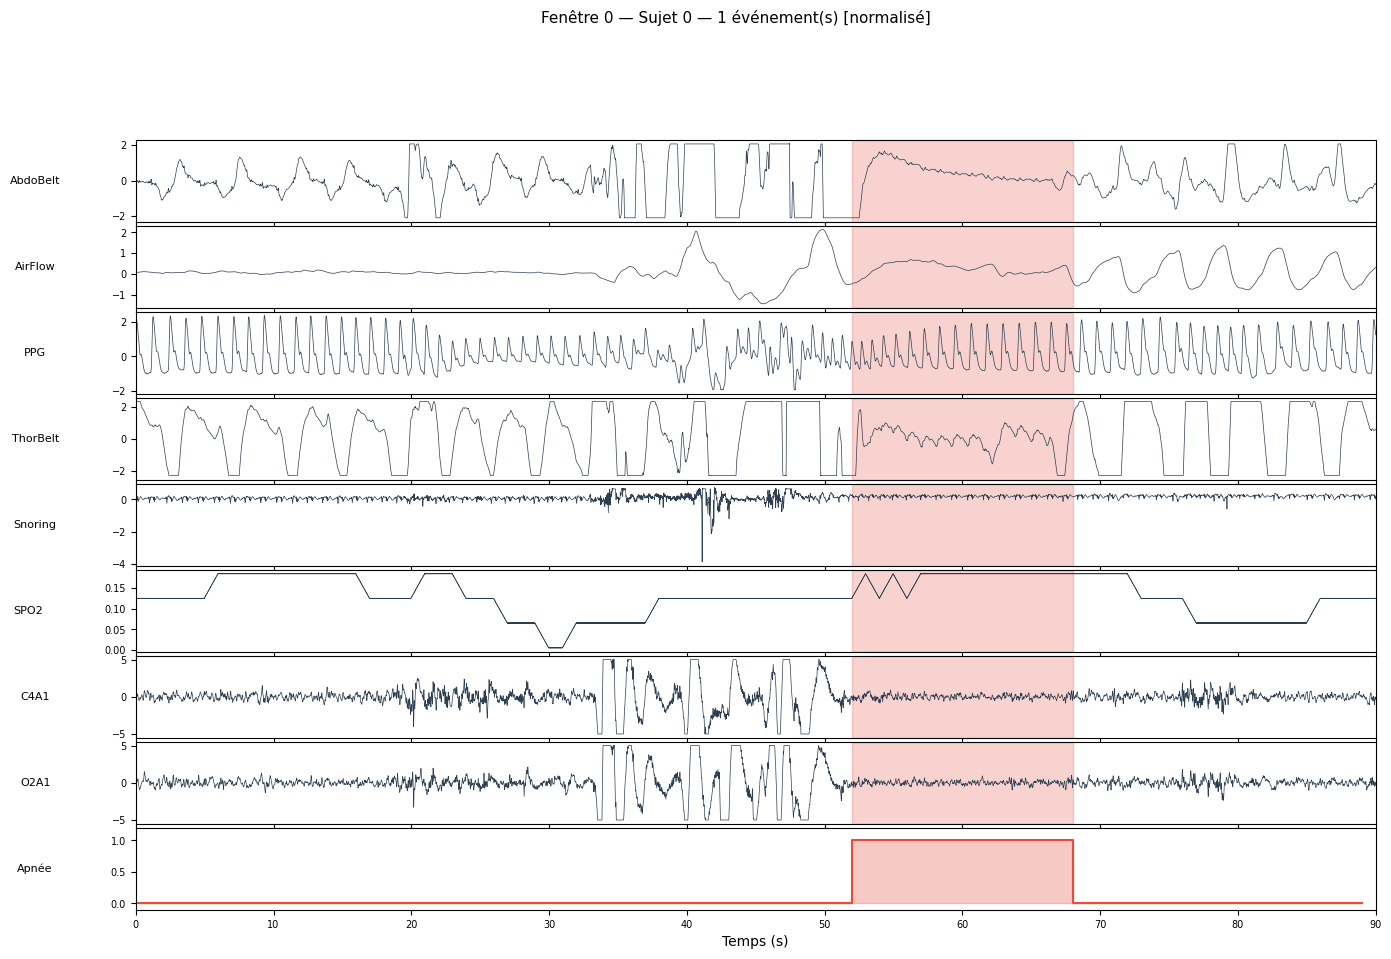

In [10]:
# Même fenêtre après normalisation
plot_window(windows_with_apnea[0], signals_norm, labels, normalized=True)

## 7. Corrélation inter-signaux

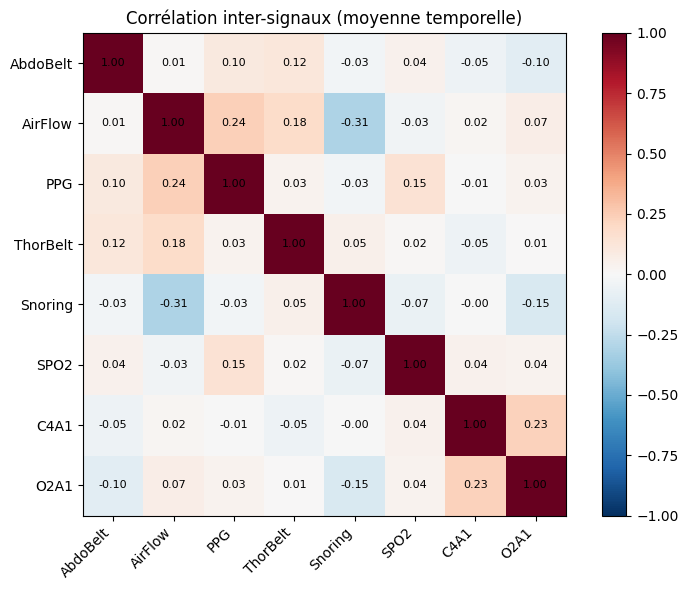

In [11]:
# Corrélation moyenne entre signaux (sur quelques fenêtres)
n_sample = 200
sample_idx = np.random.choice(len(signals), n_sample, replace=False)

# Moyenne temporelle par canal par fenêtre → (n_sample, 8)
features = signals[sample_idx].mean(axis=2)  # (200, 8)
corr_matrix = np.corrcoef(features.T)         # (8, 8)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xticklabels(SIGNAL_NAMES, rotation=45, ha='right')
ax.set_yticklabels(SIGNAL_NAMES)
ax.set_title('Corrélation inter-signaux (moyenne temporelle)')

for i in range(8):
    for j in range(8):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Signaux pendant vs hors apnée

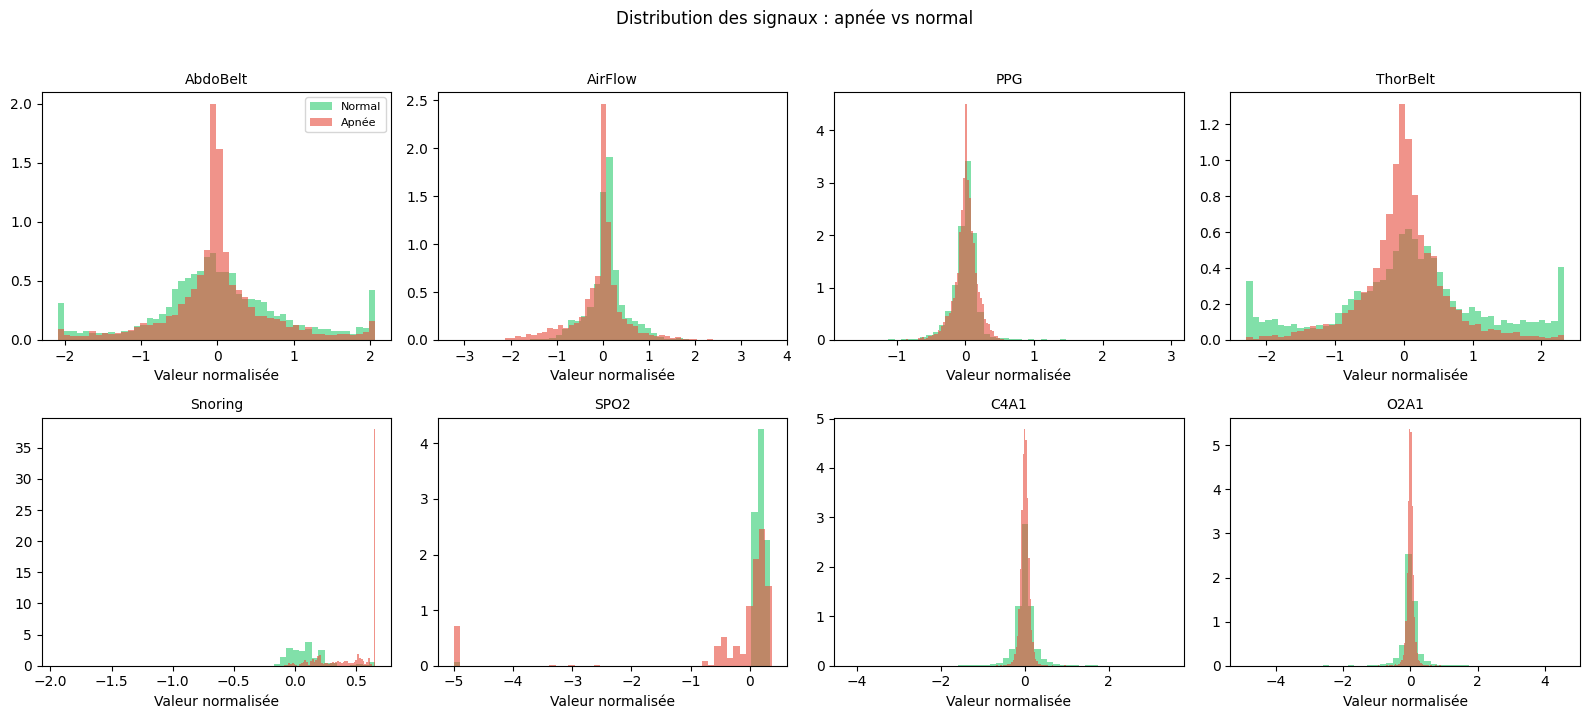

: 

In [ ]:
# Comparer les distributions des signaux durant/hors événements
# On travaille sur signaux normalisés, à 1Hz (moyenne par seconde)

# Downsampler les signaux à 1Hz (moyenne sur blocs de 100 samples)
signals_1hz = signals_norm.reshape(4400, 8, 90, 100).mean(axis=-1)  # (4400, 8, 90)

# Séparer les instants apnée / non-apnée
label_flat = labels.reshape(-1).astype(bool)          # (4400*90,)
sig_flat = signals_1hz.transpose(0, 2, 1).reshape(-1, 8)  # (4400*90, 8)

apnea_vals = sig_flat[label_flat]      # instants avec apnée
normal_vals = sig_flat[~label_flat]    # instants sans apnée

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for i, (ax, name) in enumerate(zip(axes, SIGNAL_NAMES)):
    ax.hist(normal_vals[:5000, i], bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    ax.hist(apnea_vals[:5000, i],  bins=50, alpha=0.6, color='#e74c3c', label='Apnée', density=True)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Valeur normalisée')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Distribution des signaux : apnée vs normal', y=1.02)
plt.tight_layout()
plt.show()